# Open Field Test — NWB Data Access Demo

**Dataset:** Meletis Lab, Karolinska Institutet  
**Publication:** [Mantas et al. (2024) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)  

This notebook demonstrates how to access each data stream in the Open Field Test (OFT) NWB files.

## About the experiment

Mice explored a 40×40 cm arena with a transparent floor, recorded from below at 30 fps.
The OFT was used to study locomotion and behavioral motifs in mouse models of Parkinson's disease.
Seven sub-experiments were conducted across multiple dopamine-related genetic and lesion models
(6-OHDA, Anxa1-TetTox, MitoPark, anti-Anxa1 antibody).

## Data streams per NWB file

| Stream | NWB location | Rate | Description |
|--------|-------------|------|-------------|
| **Video** | `acquisition/Video {name}` | 30 fps | External reference to MP4 file (not embedded) |
| **Pose estimation** | `processing/behavior/PoseEstimationDeepLabCut` | 30 Hz | DeepLabCut output — 6 keypoints (x, y, confidence) |
| **VAME motifs** | `processing/behavior/VAMEProject{157,36}` | 30 Hz | `VAMEProject` container holding a `MotifSeries` of integer k-means labels per frame; linked back to `PoseEstimationDeepLabCut`. Access labels via `project.motif_series.data[:]`. |
| **Fiber photometry** | `acquisition/FiberPhotometryResponseSeries` | ~60 Hz | Motion-corrected dLight/GCaMP signal (sig − ref) |
| **Kinematics** | `processing/behavior/Kinematics` | 30 Hz | Derived speed, acceleration, angular speed, distance metrics |

Not all streams are present in every session. Fiber photometry is only available for the
`oft_fp` sub-experiment (31 of 161 sessions). VAME motifs are available for 157 sessions
(157-motif model) and 36 sessions (36-motif model). The directory names `vame_157` / `vame_36`
refer to the VAME latent-space dimension used during training; both models use **47 k-means
clusters** (labels 0–46).

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Load NWB file

Update the path below to point to your NWB file. This demo uses a stub (truncated) file
for quick testing; full files have the same structure with longer time series.

In [2]:
nwb_path = "../../../nwb_output/open_field_test/nwb_stub/sub-687643_ses-oft_2023-05-16T15_31_06.nwb"

io = NWBHDF5IO(nwb_path, mode="r")
nwbfile = io.read()

print(f"Session ID:    {nwbfile.session_id}")
print(f"Session start: {nwbfile.session_start_time}")
print(f"Subject ID:    {nwbfile.subject.subject_id}")
print(f"Species:       {nwbfile.subject.species}")
print(f"Genotype:      {nwbfile.subject.genotype}")
print(f"Sex:           {nwbfile.subject.sex}")
print(f"Institution:   {nwbfile.institution}")
print(f"Lab:           {nwbfile.lab}")

Session ID:    oft_Tetx
Session start: 2023-05-16 15:31:06+02:00
Subject ID:    687643
Species:       Mus musculus
Genotype:      anxa1-flp
Sex:           M
Institution:   Karolinska Institutet
Lab:           Meletis


## 1. Video (external reference)

Videos are stored as external file references rather than embedded pixel data.
Each session has one MP4 video (H.264, 30 fps, ~856×818 pixels) recorded from below
through a transparent floor. The `external_file` field contains the path to the video.

In [3]:
video_keys = list(nwbfile.acquisition.keys())
video_series = [k for k in video_keys if "Video" in k or "video" in k.lower()]

if video_series:
    video = nwbfile.acquisition[video_series[0]]
    print(f"Video name:      {video.name}")
    print(f"External file:   {video.external_file[0]}")
    print(f"Starting time:   {video.starting_time} s")
    print(f"Rate:            {video.rate} fps")
else:
    print("No video found in this NWB file.")

Video name:      Video oft_2023-05-16T15_31_06
External file:   /Volumes/T9/data/Meletis/oft/videos/oft_2023-05-16T15_31_06.mp4
Starting time:   0.0 s
Rate:            30.0 fps


## 2. Pose estimation (DeepLabCut)

Pose estimation was performed using DeepLabCut, tracking 6 keypoints on each mouse:
**snout**, **left front paw**, **right front paw**, **left back paw**, **right back paw**,
and **tail base**. Stored via the [ndx-pose](https://github.com/rly/ndx-pose) extension.

Each keypoint has:
- `data` — (N, 2) array of (x, y) pixel coordinates at 30 Hz
- `confidence` — (N,) array of DLC likelihood scores per frame

In [4]:
behavior = nwbfile.processing["behavior"]
pose = behavior["PoseEstimationDeepLabCut"]

# List all keypoints
keypoint_names = [k.replace("PoseEstimationSeries", "") for k in pose.pose_estimation_series]
print(f"Keypoints ({len(keypoint_names)}): {keypoint_names}")
print(f"Scorer: {pose.scorer}")
print(f"Source software: {pose.source_software}")

# Access a single keypoint
snout = pose.pose_estimation_series["PoseEstimationSeriesSnout"]
print(f"\nSnout data shape: {snout.data.shape}  (frames × [x, y])")
print(f"Confidence shape:  {snout.confidence.shape}")
print(f"Number of frames:  {snout.data.shape[0]}")

Keypoints (6): ['Leftbackpaw', 'Leftfrontpaw', 'Rightbackpaw', 'Rightfrontpaw', 'Snout', 'Tailbase']
Scorer: DLC_resnet50_oft_roomIVASep13shuffle1_950000
Source software: DeepLabCut

Snout data shape: (9000, 2)  (frames × [x, y])
Confidence shape:  (9000,)
Number of frames:  9000


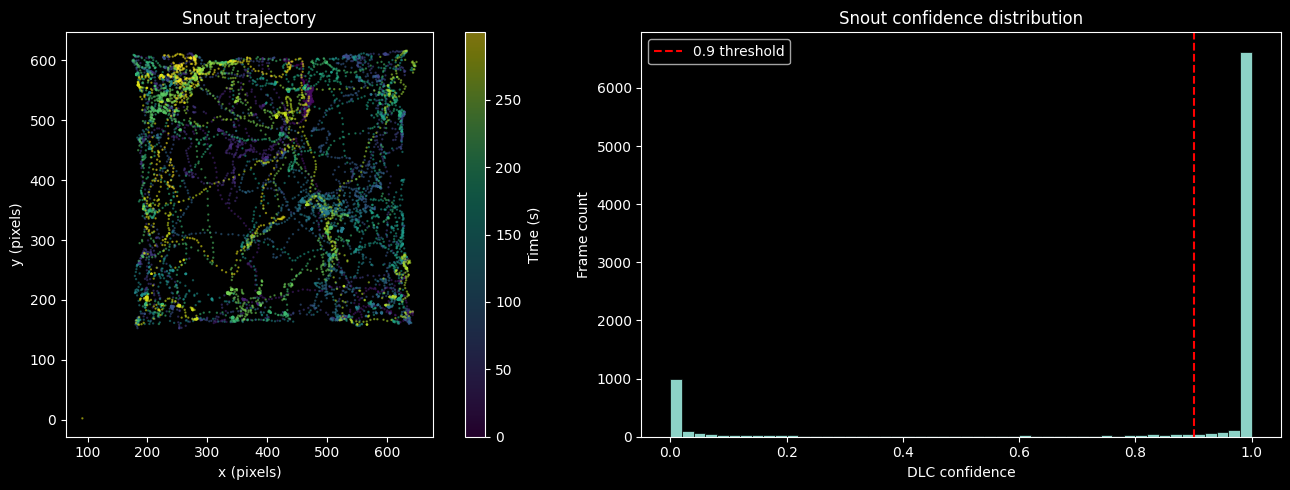

In [5]:
# Plot trajectory of the snout
snout_xy = snout.data[:]
confidence = snout.confidence[:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trajectory colored by time
ax = axes[0]
n_frames = len(snout_xy)
time_s = np.arange(n_frames) / 30.0
sc = ax.scatter(snout_xy[:, 0], snout_xy[:, 1], c=time_s, s=0.5, cmap="viridis", alpha=0.5)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Snout trajectory")
ax.set_aspect("equal")
plt.colorbar(sc, ax=ax, label="Time (s)")

# Confidence histogram
ax = axes[1]
ax.hist(confidence, bins=50, edgecolor="black", linewidth=0.5)
ax.set_xlabel("DLC confidence")
ax.set_ylabel("Frame count")
ax.set_title("Snout confidence distribution")
ax.axvline(0.9, color="red", linestyle="--", label="0.9 threshold")
ax.legend()

plt.tight_layout()
plt.show()

## 3. VAME behavioral motifs

[VAME](https://github.com/EthoML/VAME) (Variational Animal Motion Embedding) was applied
for unsupervised behavioral classification. Each video frame is assigned an integer motif label
via k-means clustering of the VAME latent space.

Two VAME models were applied to this dataset:
- **157-dim model** (`VAMEProject157`) — latent space of dimension 157, 47 k-means clusters
- **36-dim model** (`VAMEProject36`) — latent space of dimension 36, 47 k-means clusters

Both are stored as `VAMEProject` containers (ndx-vame extension) inside
`processing/behavior/`. Each project holds a `MotifSeries` of integer labels at 30 Hz and is
linked to `PoseEstimationDeepLabCut` (the pose input used for VAME training).

Access pattern:
```python
project = nwbfile.processing["behavior"]["VAMEProject157"]
labels  = project.motif_series.data[:]        # 1D int array, one label per frame
pose    = project.pose_estimation             # PoseEstimation object (linked)
```

VAMEProject157:
  MotifSeries name:      VAMEMotifs157
  Shape:                 (8970,)  (299.0 s at 30.0 Hz)
  Unique motifs:         44  (labels 0–46)
  Description:           VAME behavioral motif labels (k-means, latent dim 157) — one integer label per video frame identifying the closest cluster centroid.
  Pose estimation linked: True
    → PoseEstimationDeepLabCut

VAMEProject36:
  MotifSeries name:      VAMEMotifs36
  Shape:                 (8970,)  (299.0 s at 30.0 Hz)
  Unique motifs:         43  (labels 0–46)
  Description:           VAME behavioral motif labels (k-means, latent dim 36) — one integer label per video frame identifying the closest cluster centroid.
  Pose estimation linked: True
    → PoseEstimationDeepLabCut



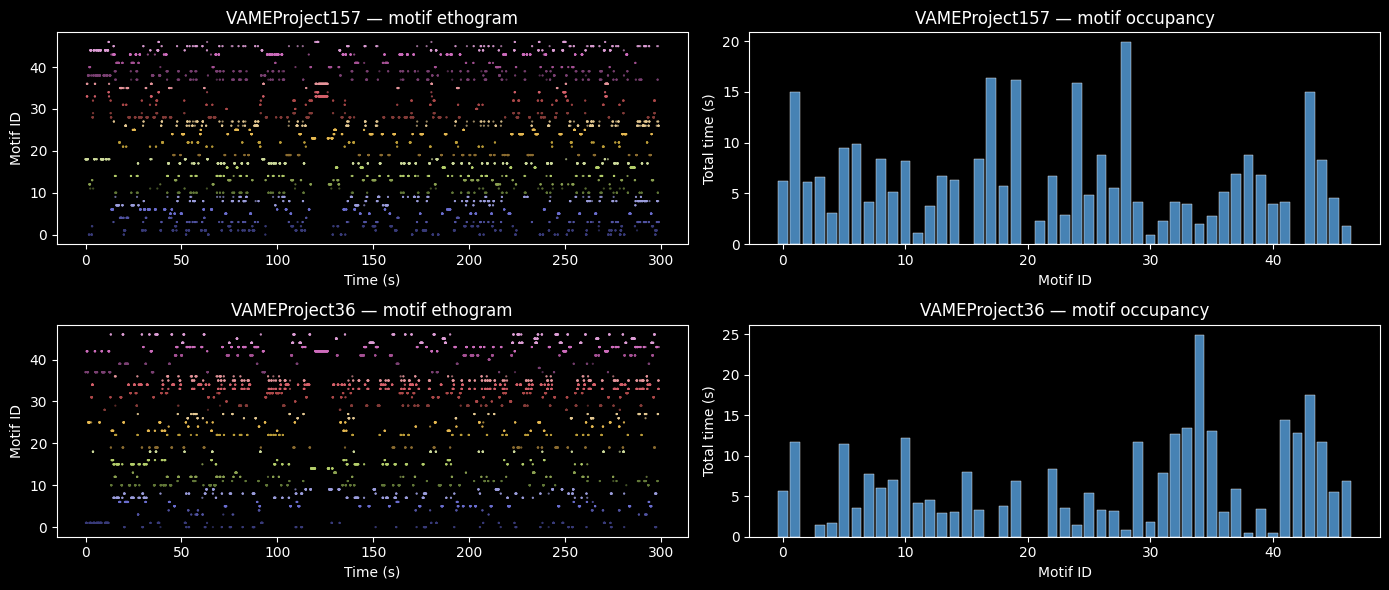

In [6]:
behavior = nwbfile.processing["behavior"]
vame_projects = {k: v for k, v in behavior.data_interfaces.items() if type(v).__name__ == "VAMEProject"}

if vame_projects:
    for key, project in vame_projects.items():
        ms = project.motif_series
        labels = np.array(ms.data[:])
        print(f"{key}:")
        print(f"  MotifSeries name:      {ms.name}")
        print(f"  Shape:                 {labels.shape}  ({labels.shape[0] / ms.rate:.1f} s at {ms.rate} Hz)")
        print(f"  Unique motifs:         {len(np.unique(labels))}  (labels {labels.min()}–{labels.max()})")
        print(f"  Description:           {ms.description}")
        print(f"  Pose estimation linked: {project.pose_estimation is not None}")
        if project.pose_estimation is not None:
            print(f"    → {project.pose_estimation.name}")
        print()

    # Ethogram and motif occupancy for both models
    fig, axes = plt.subplots(len(vame_projects), 2, figsize=(14, 3 * len(vame_projects)))
    if len(vame_projects) == 1:
        axes = [axes]

    for row_axes, (key, project) in zip(axes, vame_projects.items()):
        ms = project.motif_series
        labels = np.array(ms.data[:])
        time_s = np.arange(len(labels)) / ms.rate

        ax_eth, ax_bar = row_axes

        # Ethogram: one dot per frame coloured by motif ID
        ax_eth.scatter(time_s, labels, s=0.3, c=labels, cmap="tab20b", alpha=0.7)
        ax_eth.set_xlabel("Time (s)")
        ax_eth.set_ylabel("Motif ID")
        ax_eth.set_title(f"{key} — motif ethogram")

        # Motif occupancy bar chart
        unique, counts = np.unique(labels, return_counts=True)
        ax_bar.bar(unique, counts / ms.rate, color="steelblue", edgecolor="white", linewidth=0.3)
        ax_bar.set_xlabel("Motif ID")
        ax_bar.set_ylabel("Total time (s)")
        ax_bar.set_title(f"{key} — motif occupancy")

    plt.tight_layout()
    plt.show()
else:
    print("No VAMEProject data in this session.")

## 4. Fiber photometry

Fiber photometry recorded dopamine/calcium dynamics in a subset of sessions (`oft_fp`
sub-experiment, 31 of 161 sessions). The signal is a motion-corrected dF/F (470 nm signal
minus 405 nm isosbestic reference) sampled at ~60 Hz.

All groups use the same Doric 400 µm cannula (`optical_fiber_cpu`) implanted in the dCP or cCP.
For GCaMP groups the virus is injected into the SNc but the **fiber is in the dCP**
to record axonal signals from SN→dCP projections.

| Group | Location | Indicator | Fiber insertion |
|-------|----------|-----------|-----------------|
| `dLight_dStr` | Dorsal caudoputamen | dLight1.3b | dCP (AP +0.74, ML ±1.5, DV −2.2) |
| `dLight_vStr` | Central caudoputamen | dLight1.3b | cCP (AP +0.38, ML +2.0, DV −2.9) |
| `fp_dat` / `dat-cre` | Dorsal caudoputamen | jGCaMP8m | dCP (AP +0.74, ML ±1.5, DV −2.2) |
| `fp_anxa1` / `anxa1-flp` | Dorsal caudoputamen | jGCaMP8m | dCP (AP +0.74, ML ±1.5, DV −2.2) |

**Note:** Timestamps start at ~5–8 s due to system warm-up. Video and FP clocks are
synchronized by Bonsai at session start.

In [7]:
if "FiberPhotometryResponseSeries" in nwbfile.acquisition:
    fp = nwbfile.acquisition["FiberPhotometryResponseSeries"]
    signal = fp.data[:]
    timestamps = fp.timestamps[:]

    print(f"Description: {fp.description}")
    print(f"Unit: {fp.unit}")
    print(f"Data shape: {signal.shape}")
    print(f"Time range: {timestamps[0]:.2f} – {timestamps[-1]:.2f} s")
    print(f"Sampling rate: ~{1 / np.median(np.diff(timestamps)):.1f} Hz")

    # Fiber photometry metadata
    fp_meta = nwbfile.lab_meta_data["fiber_photometry"]
    fp_table = fp_meta.fiber_photometry_table
    print(f"\nRecording location: {fp_table['location'][0]}")
    print(f"Excitation wavelength: {fp_table['excitation_wavelength_in_nm'][0]} nm")
    print(f"Emission wavelength: {fp_table['emission_wavelength_in_nm'][0]} nm")
else:
    signal = None
    print("No fiber photometry data in this session.")
    print("Fiber photometry is available in 31 sessions (oft_fp sub-experiment).")

No fiber photometry data in this session.
Fiber photometry is available in 31 sessions (oft_fp sub-experiment).


In [8]:
if signal is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    # Full trace
    axes[0].plot(timestamps, signal, linewidth=0.3, color="green")
    axes[0].set_ylabel("Signal (a.u.)")
    axes[0].set_title("Fiber photometry — full session")

    # Zoomed 60-second window
    t_start = timestamps[0]
    t_end = min(t_start + 60, timestamps[-1])
    mask = (timestamps >= t_start) & (timestamps <= t_end)
    axes[1].plot(timestamps[mask], signal[mask], linewidth=0.5, color="green")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Signal (a.u.)")
    axes[1].set_title(f"Fiber photometry — first 60 s (from {t_start:.1f} s)")

    plt.tight_layout()
    plt.show()

## 5. Kinematics

Derived kinematics computed from the pose estimation data, stored in
`processing/behavior/Kinematics` as a `BehavioralTimeSeries` container at 30 Hz.

| Time series | Unit | Description |
|-------------|------|-------------|
| `speed` | pixels/s | Movement speed of the body center |
| `acceleration` | pixels/s² | Movement acceleration of the body center |
| `angular_speed` | rad/s | Angular speed of body orientation |
| `distance_moved` | pixels | Distance moved by the body center per frame |
| `angular_distance` | rad | Angular distance of body orientation change per frame |
| `speed_snout` | pixels/s | Movement speed of the snout |
| `distance_moved_snout` | pixels | Distance moved by the snout per frame |

Note: `acceleration` is only available in sessions that used the 157-session aligned model.

In [9]:
if "Kinematics" in behavior.data_interfaces:
    kinematics = behavior["Kinematics"]
    print("Available kinematics time series:")
    for name, ts in kinematics.time_series.items():
        data = ts.data[:]
        print(f"  {name:25s}  shape={str(data.shape):12s}  unit={ts.unit:12s}  range=[{data.min():.2f}, {data.max():.2f}]")
else:
    kinematics = None
    print("No Kinematics in this session (requires an aligned CSV from the oft_Tetx / oft_fp pipeline).")

No Kinematics in this session (requires an aligned CSV from the oft_Tetx / oft_fp pipeline).


In [10]:
if kinematics is not None:
    # Plot speed and angular speed
    speed = kinematics.time_series["speed"]
    speed_data = speed.data[:]
    speed_time = np.arange(len(speed_data)) / speed.rate

    angular_speed = kinematics.time_series["angular_speed"]
    angular_data = angular_speed.data[:]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    axes[0].plot(speed_time, speed_data, linewidth=0.3, color="steelblue")
    axes[0].set_ylabel(f"Speed ({speed.unit})")
    axes[0].set_title("Body center speed")

    axes[1].plot(speed_time, angular_data, linewidth=0.3, color="darkorange")
    axes[1].set_ylabel(f"Angular speed ({angular_speed.unit})")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Angular speed")

    plt.tight_layout()
    plt.show()

## 6. NWB file structure overview

Summary of all containers in this NWB file.

In [11]:
print("=== Acquisition ===")
for name, obj in nwbfile.acquisition.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Processing ===")
for mod_name, module in nwbfile.processing.items():
    print(f"  {mod_name}/")
    for name, obj in module.data_interfaces.items():
        print(f"    {name}: {type(obj).__name__}")

print("\n=== Devices ===")
for name in nwbfile.devices:
    print(f"  {name}")

print("\n=== Lab metadata ===")
for name in nwbfile.lab_meta_data:
    print(f"  {name}")

=== Acquisition ===
  Video oft_2023-05-16T15_31_06: ImageSeries

=== Processing ===
  behavior/
    PoseEstimationDeepLabCut: PoseEstimation
    Skeletons: Skeletons
    VAMEProject157: VAMEProject
    VAMEProject36: VAMEProject

=== Devices ===
  CameraPoseEstimationDeepLabCut
  None Camera Device

=== Lab metadata ===


In [12]:
io.close()